In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/raw/customer_data.csv')

print("=" * 60)
print("CHURN PREDICTION MODEL")
print("=" * 60)

# Create churn target variable
# Customers with last_purchase > 180 days are considered churned
df['churned'] = (df['last_purchase_days_ago'] > 180).astype(int)

print(f"\nDataset Shape: {df.shape}")
print(f"\nChurn Distribution:")
print(df['churned'].value_counts())
print(f"\nChurn Rate: {df['churned'].mean()*100:.2f}%")

# Display first few rows
print(f"\nFirst 5 rows:")
print(df.head())

CHURN PREDICTION MODEL

Dataset Shape: (1000, 10)

Churn Distribution:
churned
0    510
1    490
Name: count, dtype: int64

Churn Rate: 49.00%

First 5 rows:
   customer_id signup_date  age country  total_purchases  total_spent  \
0            1  2023-11-24   56  Canada               19         2476   
1            2  2023-02-27   69  France               30         3109   
2            3  2023-01-13   46      UK                7         3093   
3            4  2023-05-21   32     USA               10         1062   
4            5  2023-05-06   60   India               41         3732   

   last_purchase_days_ago  avg_order_value  is_active  churned  
0                     313              406          1        1  
1                      49              389          1        0  
2                     118              253          1        0  
3                      54              210          0        0  
4                     138               77          0        0  


In [2]:
# Create features for the model
features_df = df.copy()

# Encode categorical variables
le_country = LabelEncoder()
features_df['country_encoded'] = le_country.fit_transform(features_df['country'])

# Select features for model
X = features_df[['age', 'total_purchases', 'total_spent', 'avg_order_value', 
                   'last_purchase_days_ago', 'is_active', 'country_encoded']]
y = features_df['churned']

print("\n" + "=" * 60)
print("FEATURES FOR MODEL")
print("=" * 60)
print(f"\nFeatures selected: {list(X.columns)}")
print(f"\nFeature Statistics:")
print(X.describe())

print(f"\nTarget Variable (Churn):")
print(f"  0 (Not Churned): {(y==0).sum()} customers")
print(f"  1 (Churned): {(y==1).sum()} customers")


FEATURES FOR MODEL

Features selected: ['age', 'total_purchases', 'total_spent', 'avg_order_value', 'last_purchase_days_ago', 'is_active', 'country_encoded']

Feature Statistics:
               age  total_purchases  total_spent  avg_order_value  \
count  1000.000000      1000.000000     1000.000      1000.000000   
mean     49.857000        24.363000     2505.241       284.007000   
std      18.114267        13.977718     1368.109       129.096665   
min      18.000000         1.000000      106.000        50.000000   
25%      35.000000        12.000000     1340.250       176.000000   
50%      50.000000        24.000000     2422.000       282.500000   
75%      66.000000        36.000000     3729.250       400.000000   
max      79.000000        49.000000     4997.000       499.000000   

       last_purchase_days_ago    is_active  country_encoded  
count             1000.000000  1000.000000      1000.000000  
mean               180.694000     0.688000         2.506000  
std         

In [3]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "=" * 60)
print("DATA SPLIT")
print("=" * 60)
print(f"\nTraining Set Size: {X_train.shape[0]} samples")
print(f"Testing Set Size: {X_test.shape[0]} samples")
print(f"\nTraining Set Churn Rate: {y_train.mean()*100:.2f}%")
print(f"Testing Set Churn Rate: {y_test.mean()*100:.2f}%")


DATA SPLIT

Training Set Size: 800 samples
Testing Set Size: 200 samples

Training Set Churn Rate: 48.50%
Testing Set Churn Rate: 51.00%


In [4]:
# Train Random Forest Classifier
print("\n" + "=" * 60)
print("TRAINING MODEL")
print("=" * 60)

model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("\n✅ Model Training Complete!")

# Model Performance
print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"\nAccuracy: {model.score(X_test_scaled, y_test):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))


TRAINING MODEL

✅ Model Training Complete!

MODEL PERFORMANCE

Accuracy: 1.0000
ROC-AUC Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

 Not Churned       1.00      1.00      1.00        98
     Churned       1.00      1.00      1.00       102

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200




FEATURE IMPORTANCE
                  feature  importance
4  last_purchase_days_ago    0.912438
2             total_spent    0.023010
3         avg_order_value    0.021041
1         total_purchases    0.018157
0                     age    0.015389
6         country_encoded    0.008106
5               is_active    0.001859


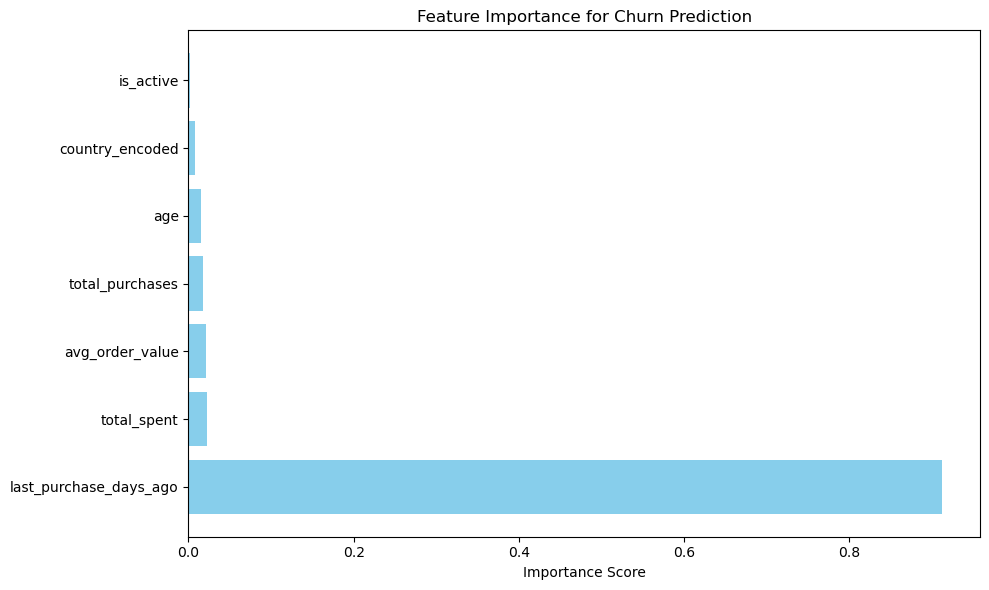

In [5]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)
print(feature_importance)

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance for Churn Prediction')
plt.tight_layout()
plt.show()

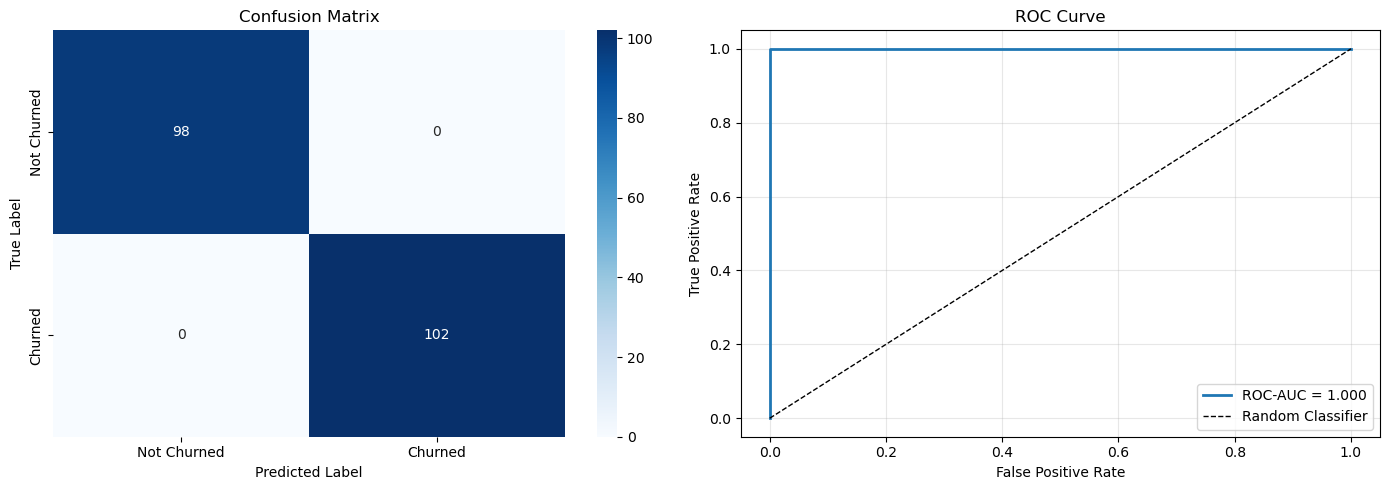

In [6]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_xticklabels(['Not Churned', 'Churned'])
axes[0].set_yticklabels(['Not Churned', 'Churned'])

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC-AUC = {roc_auc_score(y_test, y_pred_proba):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Add predictions to test data
test_results = X_test.copy()
test_results['actual_churn'] = y_test.values
test_results['predicted_churn'] = y_pred
test_results['churn_probability'] = y_pred_proba

# Sort by churn probability (highest risk first)
high_risk = test_results[test_results['churn_probability'] > 0.7].sort_values('churn_probability', ascending=False)

print("\n" + "=" * 60)
print("HIGH-RISK CUSTOMERS (>70% churn probability)")
print("=" * 60)
print(f"\nFound {len(high_risk)} high-risk customers")
print(high_risk.head(10))

# Save predictions
test_results.to_csv('../data/processed/churn_predictions.csv', index=False)
print("\n✅ Predictions saved to: data/processed/churn_predictions.csv")


HIGH-RISK CUSTOMERS (>70% churn probability)

Found 102 high-risk customers
     age  total_purchases  total_spent  avg_order_value  \
865   36                4         3706              345   
355   52                6         1383              382   
158   51               16         2628              191   
445   38               41         2004              176   
589   36               15         3411              357   
810   56                3         3219              467   
235   56               18         2397              429   
208   53               16         1961               94   
534   33               13         4105              420   
101   79                8         3079              260   

     last_purchase_days_ago  is_active  country_encoded  actual_churn  \
865                     339          1                1             1   
355                     343          1                0             1   
158                     333          1                

OSError: Cannot save file into a non-existent directory: '..\data\processed'